In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('BlackFriday.csv')

In [3]:
df

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969
...,...,...,...,...,...,...,...,...,...,...,...,...
537572,1004737,P00193542,M,36-45,16,C,1,0,1,2.0,NaN,11664
537573,1004737,P00111142,M,36-45,16,C,1,0,1,15.0,16.0,19196
537574,1004737,P00345942,M,36-45,16,C,1,0,8,15.0,NaN,8043
537575,1004737,P00285842,M,36-45,16,C,1,0,5,NaN,NaN,7172


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 537577 entries, 0 to 537576
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     537577 non-null  int64  
 1   Product_ID                  537577 non-null  object 
 2   Gender                      537577 non-null  object 
 3   Age                         537577 non-null  object 
 4   Occupation                  537577 non-null  int64  
 5   City_Category               537577 non-null  object 
 6   Stay_In_Current_City_Years  537577 non-null  object 
 7   Marital_Status              537577 non-null  int64  
 8   Product_Category_1          537577 non-null  int64  
 9   Product_Category_2          370591 non-null  float64
 10  Product_Category_3          164278 non-null  float64
 11  Purchase                    537577 non-null  int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 49.2+ MB


In [5]:
df.isnull().sum()

User_ID                            0
Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            166986
Product_Category_3            373299
Purchase                           0
dtype: int64

In [49]:
del df['Product_Category_3']
del df['Product_Category_2']

In [12]:
df

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969
...,...,...,...,...,...,...,...,...,...,...
537572,1004737,P00193542,M,36-45,16,C,1,0,1,11664
537573,1004737,P00111142,M,36-45,16,C,1,0,1,19196
537574,1004737,P00345942,M,36-45,16,C,1,0,8,8043
537575,1004737,P00285842,M,36-45,16,C,1,0,5,7172


## Analysing Columns

In [13]:
df['User_ID'].nunique()

5891

In [15]:
df['Product_ID'].nunique()

3623

In [16]:
df['Gender'].unique()

array(['F', 'M'], dtype=object)

In [17]:
df['Age'].unique()

array(['0-17', '55+', '26-35', '46-50', '51-55', '36-45', '18-25'],
      dtype=object)

In [18]:
df['Occupation'].unique()

array([10, 16, 15,  7, 20,  9,  1, 12, 17,  0,  3,  4, 11,  8, 19,  2, 18,
        5, 14, 13,  6])

In [19]:
df['City_Category'].unique()

array(['A', 'C', 'B'], dtype=object)

In [20]:
df['Stay_In_Current_City_Years'].unique()

array(['2', '4+', '3', '1', '0'], dtype=object)

In [21]:
df['Marital_Status'].unique()

array([0, 1])

In [22]:
df['Product_Category_1'].unique()

array([ 3,  1, 12,  8,  5,  4,  2,  6, 14, 11, 13, 15,  7, 16, 18, 10, 17,
        9])

In [24]:
df['Purchase'].sum()/len(df['Purchase'])

np.float64(9333.859852635065)

In [27]:
for col in df.columns:
    print(col,':', df[col].nunique())

User_ID : 5891
Product_ID : 3623
Gender : 2
Age : 7
Occupation : 21
City_Category : 3
Stay_In_Current_City_Years : 5
Marital_Status : 2
Product_Category_1 : 18
Purchase : 17959


## Analysing Gender

In [38]:
data = pd.DataFrame({'Ratio':[len(df[df['Gender'] == 'M']) , len(df[df['Gender'] == 'F'])]},index= ['Male','Female'])
data

,Ratio
Male,405380
Female,132197


`Method 1`

<Axes: ylabel='Ratio'>

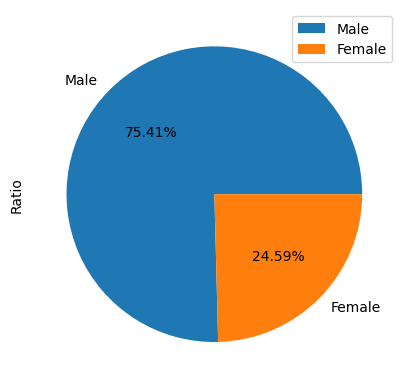

In [43]:
data.plot.pie(y='Ratio',autopct='%.2f%%')

`Method 2`

<Axes: title={'center': 'Gender Ratio'}>

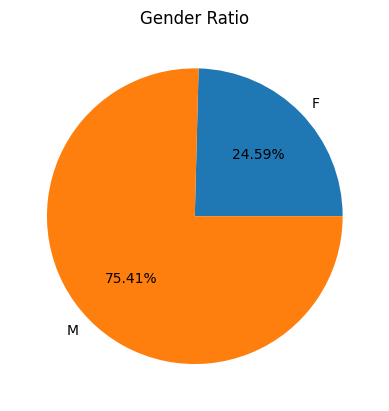

In [46]:
df.groupby('Gender').size().plot(kind='pie',autopct='%.2f%%',title="Gender Ratio")

<Axes: title={'center': 'Gender Ratio'}, xlabel='Gender'>

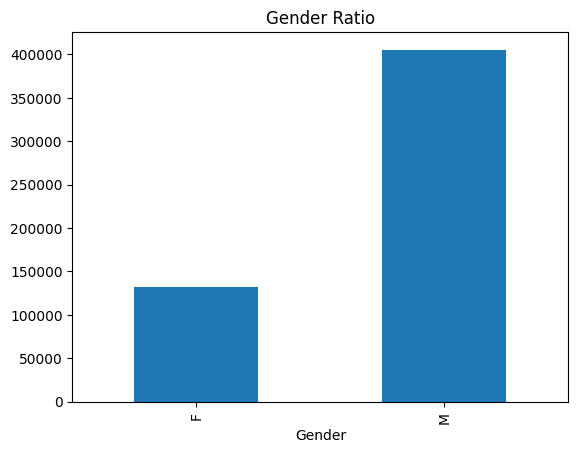

In [47]:
df.groupby('Gender').size().plot(kind='bar',title="Gender Ratio")

<Axes: title={'center': 'Purchase Ratio'}, ylabel='Purchase'>

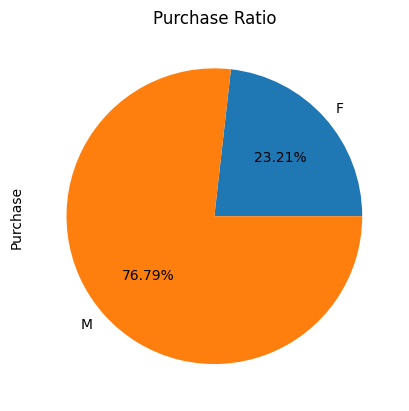

In [49]:
df.groupby('Gender')['Purchase'].sum().plot(kind='pie',autopct='%.2f%%',title='Purchase Ratio')

<Axes: title={'center': 'Purchase Ratio'}, ylabel='Purchase'>

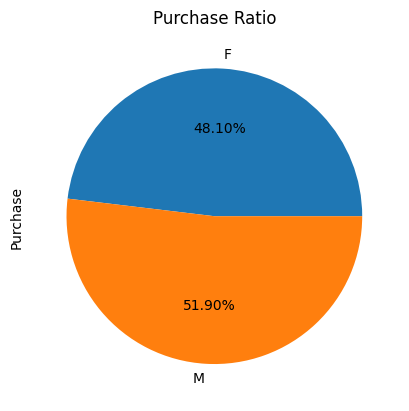

In [50]:
df.groupby('Gender')['Purchase'].mean().plot(kind='pie',autopct='%.2f%%',title='Purchase Ratio')

## Analysing Age & Marital Status

<Axes: title={'center': 'Purchase Distribution by Age'}, xlabel='Age'>

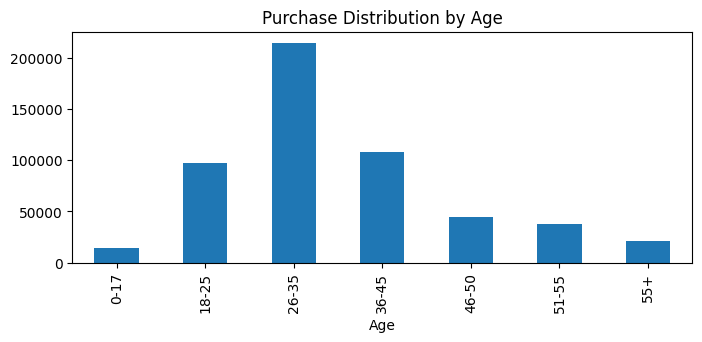

In [55]:
df.groupby('Age')['Purchase'].size().plot(kind='bar',figsize=(8,3),title='Purchase Distribution by Age')

In [68]:
lst=[]
for i in df['Age'].unique():
    lst.append((i,(df[df['Age']==i]['Product_ID'].nunique())))

data = pd.DataFrame(lst,columns=['Age','Unique Products'])

In [69]:
data

,Age,Unique Products
0,0-17,2300
1,55+,2573
2,26-35,3419
3,46-50,3099
4,51-55,2877
5,36-45,3318
6,18-25,3213


<Axes: xlabel='Age'>

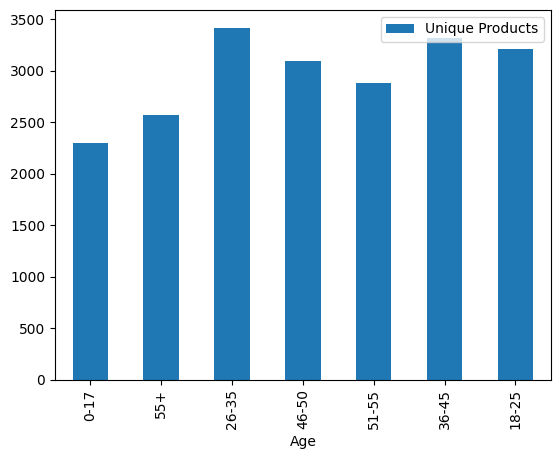

In [72]:
data.plot.bar(x='Age')

<Axes: title={'center': 'Amount spend by Age'}, xlabel='Age'>

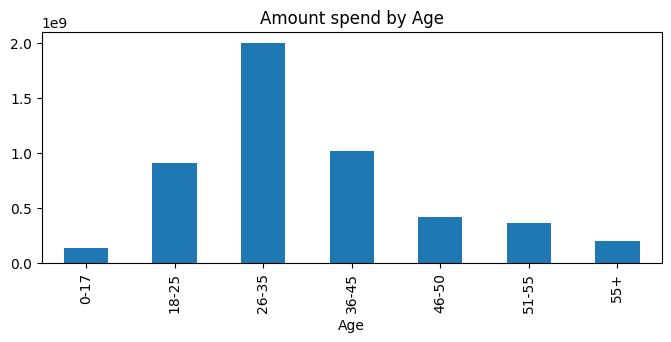

In [73]:
df.groupby('Age')['Purchase'].sum().plot(kind='bar',figsize=(8,3),title='Amount spend by Age')

<Axes: title={'center': 'Amount spend by Age'}, xlabel='Age'>

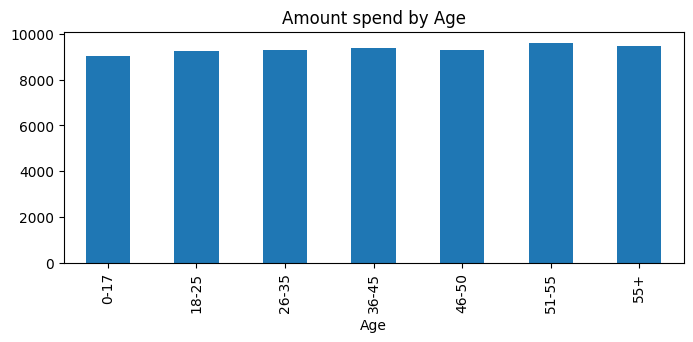

In [74]:
df.groupby('Age')['Purchase'].mean().plot(kind='bar',figsize=(8,3),title='Amount spend by Age')

<Axes: title={'center': 'Amount spend by Age'}, ylabel='Purchase'>

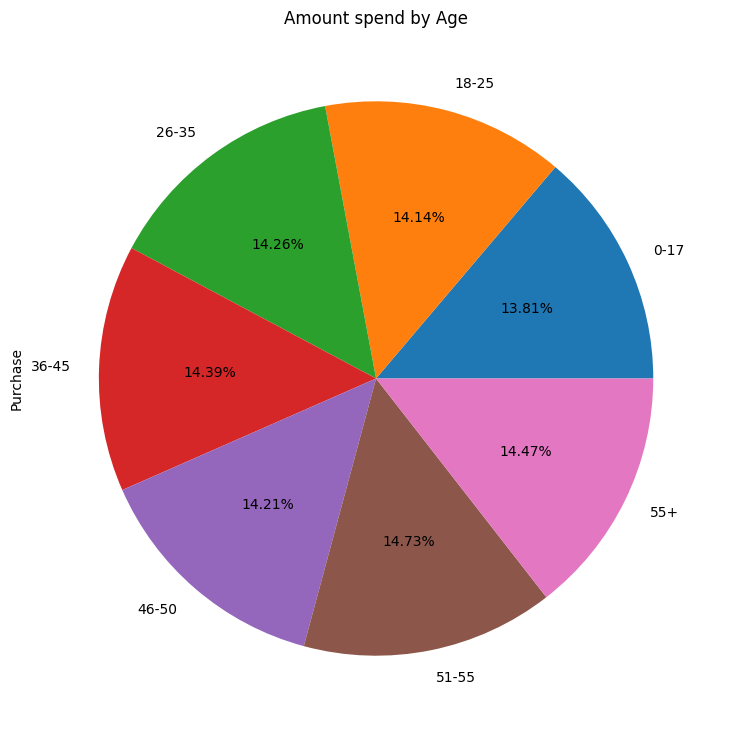

In [77]:
df.groupby('Age')['Purchase'].mean().plot(kind='pie',figsize=(9,9),autopct='%.2f%%',title='Amount spend by Age')

<Axes: title={'center': 'Marraige Ratio'}>

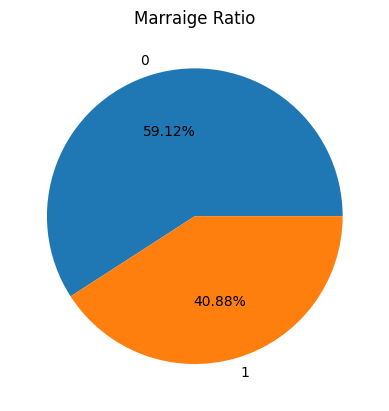

In [80]:
df.groupby('Marital_Status').size().plot.pie(autopct='%.2f%%',title="Marraige Ratio")

# MultiColumn Analysis

<Axes: xlabel='Age', ylabel='count'>

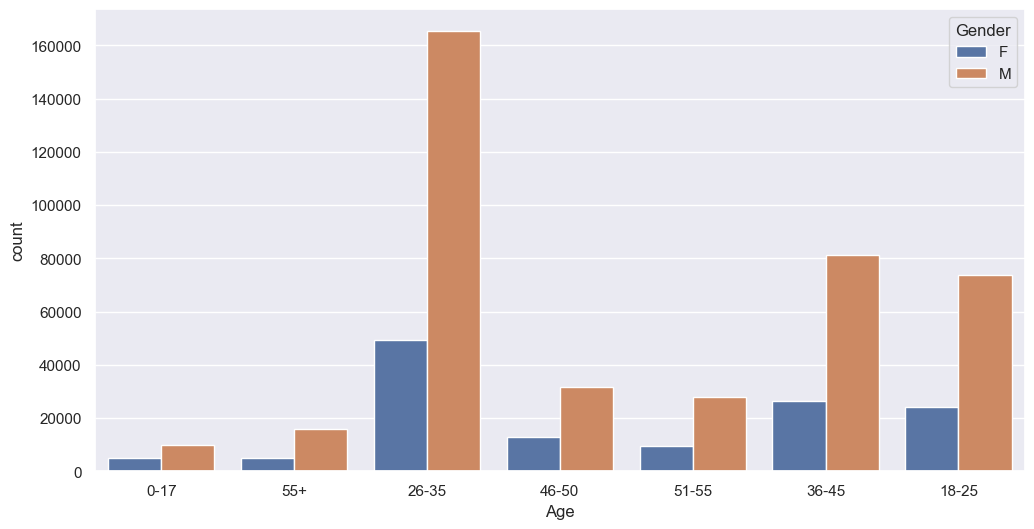

In [82]:
sns.set(rc={'figure.figsize':(12,6)})
sns.countplot(x='Age',hue='Gender',data=df)

<Axes: xlabel='Gender', ylabel='count'>

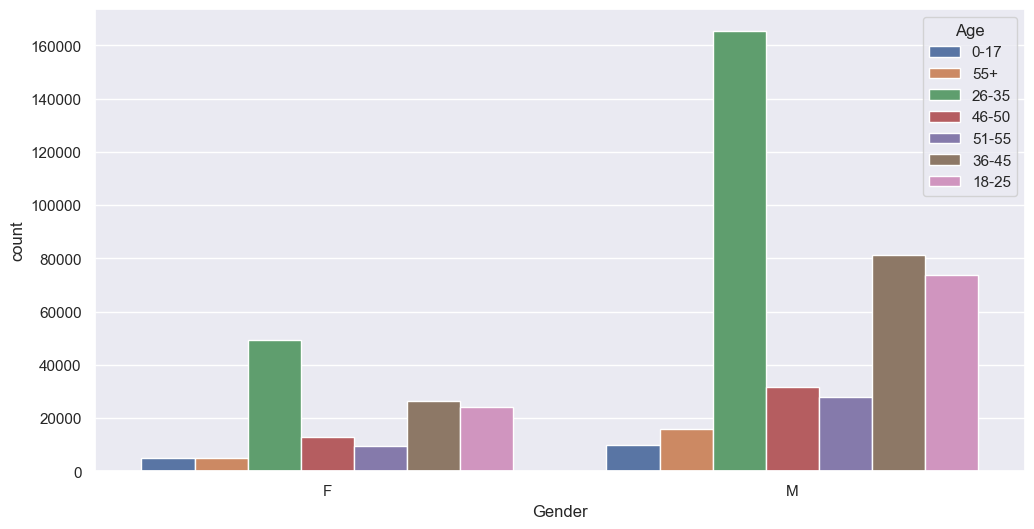

In [83]:
sns.set(rc={'figure.figsize':(12,6)})
sns.countplot(x='Gender',hue='Age',data=df)

<Axes: xlabel='Marital_Status', ylabel='count'>

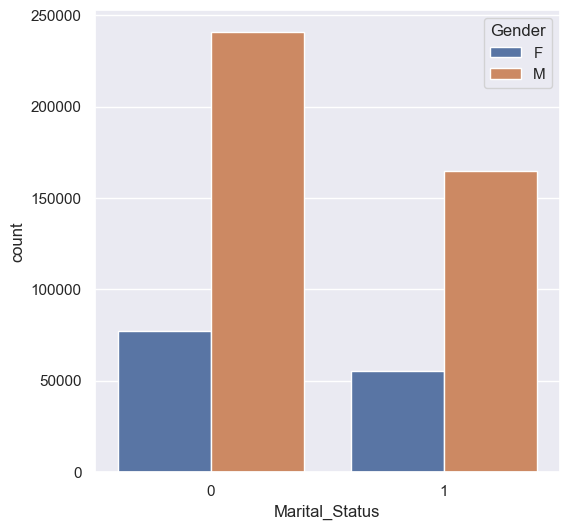

In [85]:
sns.set(rc={'figure.figsize':(6,6)})
sns.countplot(x='Marital_Status',hue='Gender',data=df)

<Axes: xlabel='Gender', ylabel='count'>

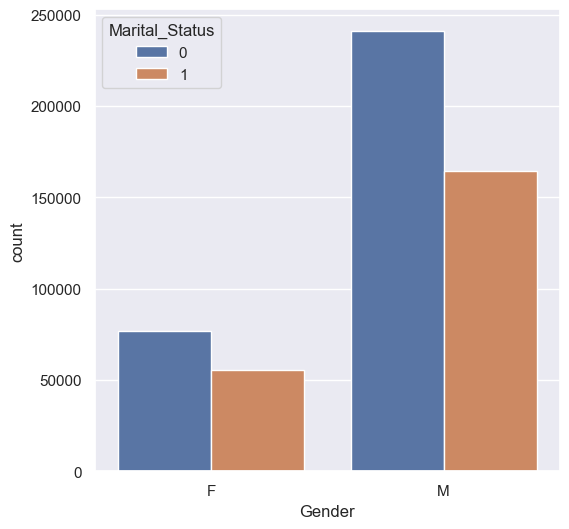

In [87]:
sns.set(rc={'figure.figsize':(6,6)})
sns.countplot(x='Gender',hue='Marital_Status',data=df)

<Axes: xlabel='City_Category', ylabel='count'>

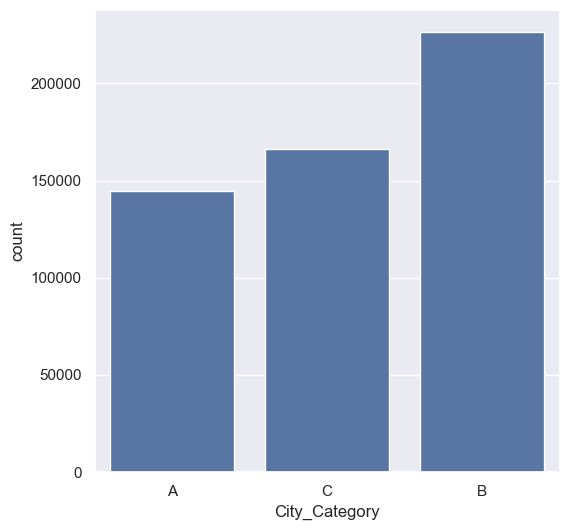

In [88]:
sns.countplot(x=df['City_Category'])

<Axes: xlabel='City_Category', ylabel='count'>

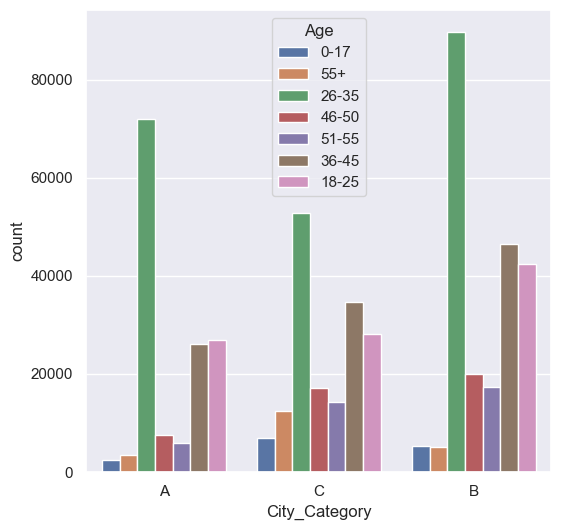

In [90]:
sns.countplot(x='City_Category',hue='Age',data=df)

<Axes: xlabel='Age', ylabel='count'>

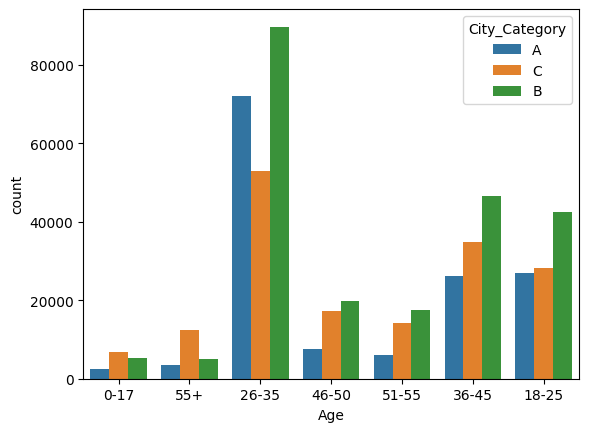

In [8]:
sns.countplot(x='Age',hue='City_Category',data=df)

<Axes: xlabel='Marital_Status', ylabel='count'>

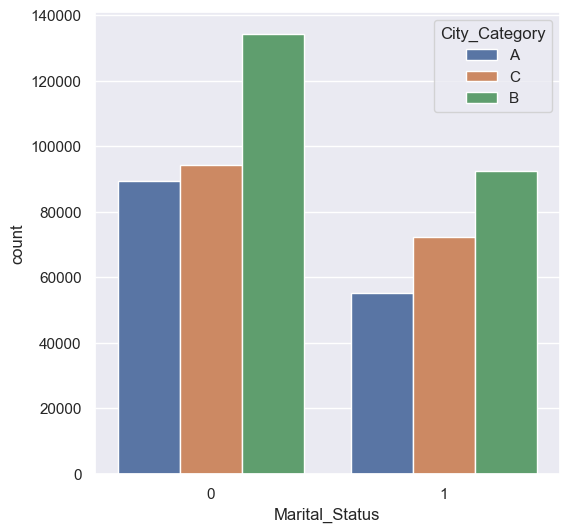

In [92]:
sns.countplot(x='Marital_Status',hue='City_Category',data=df)

<Axes: >

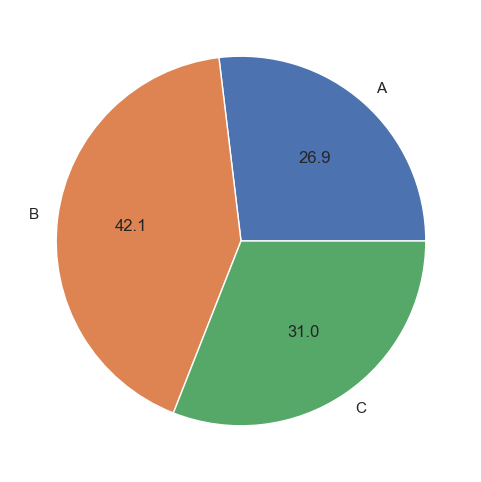

In [89]:
df.groupby('City_Category').size().plot(kind='pie',autopct='%0.1f')

<Axes: xlabel='City_Category', ylabel='count'>

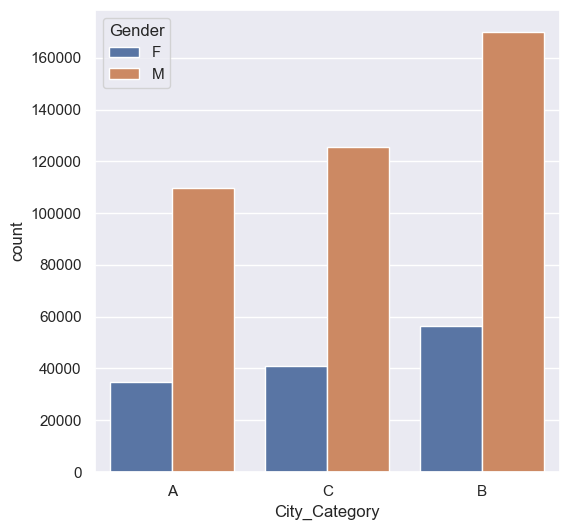

In [93]:
sns.countplot(x='City_Category',hue='Gender',data=df)

<Axes: ylabel='Purchase'>

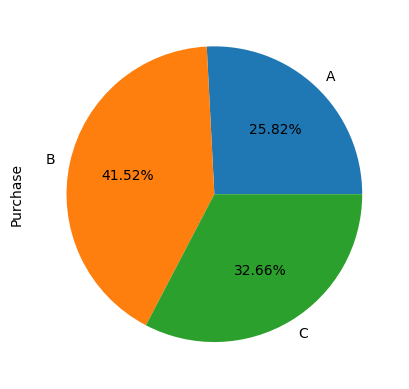

In [6]:
df.groupby('City_Category')['Purchase'].sum().plot(kind='pie',autopct='%.2f%%')

<Axes: ylabel='Purchase'>

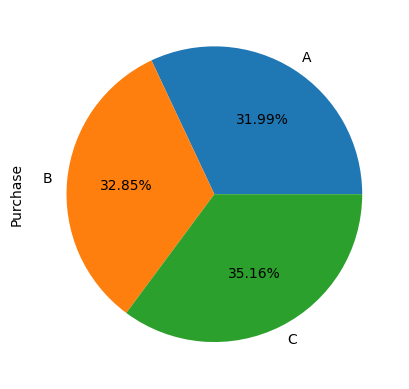

In [7]:
df.groupby('City_Category')['Purchase'].mean().plot(kind='pie',autopct='%.2f%%')

# Occupation and Products Analysis

<Axes: xlabel='Stay_In_Current_City_Years', ylabel='count'>

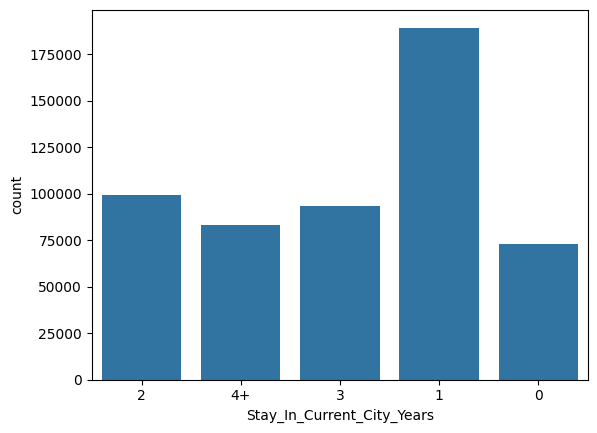

In [5]:
sns.countplot(x='Stay_In_Current_City_Years',data=df)

<Axes: >

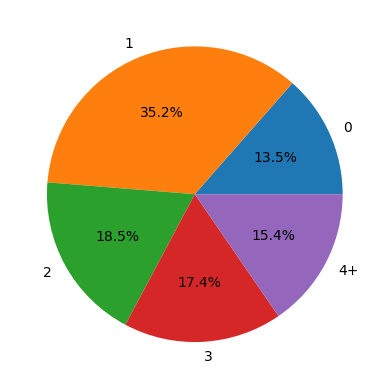

In [9]:
df.groupby('Stay_In_Current_City_Years').size().plot(kind='pie',autopct='%.1f%%')

<Axes: xlabel='Stay_In_Current_City_Years', ylabel='count'>

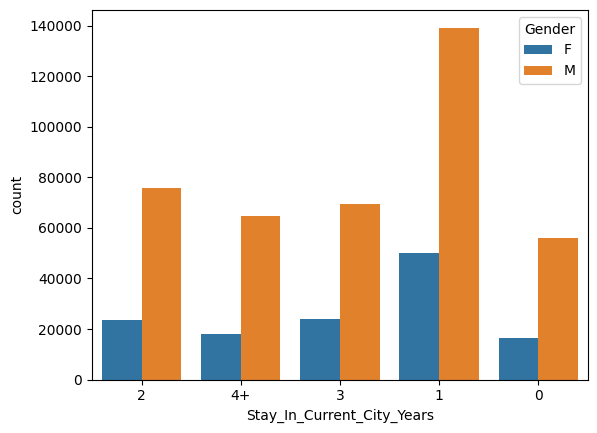

In [6]:
sns.countplot(x='Stay_In_Current_City_Years',hue='Gender',data=df)

<Axes: xlabel='Stay_In_Current_City_Years', ylabel='count'>

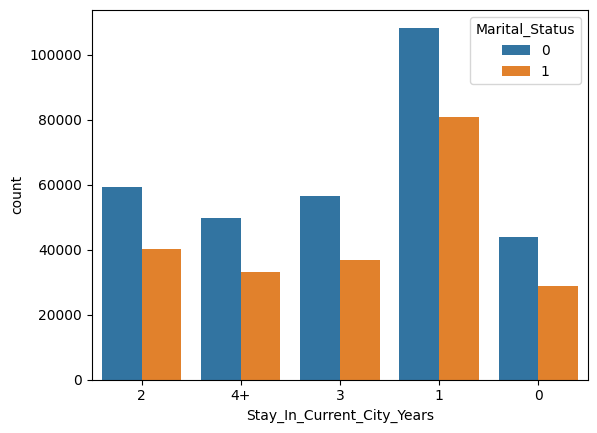

In [7]:
sns.countplot(x='Stay_In_Current_City_Years',hue='Marital_Status',data=df)

<Axes: xlabel='Stay_In_Current_City_Years', ylabel='count'>

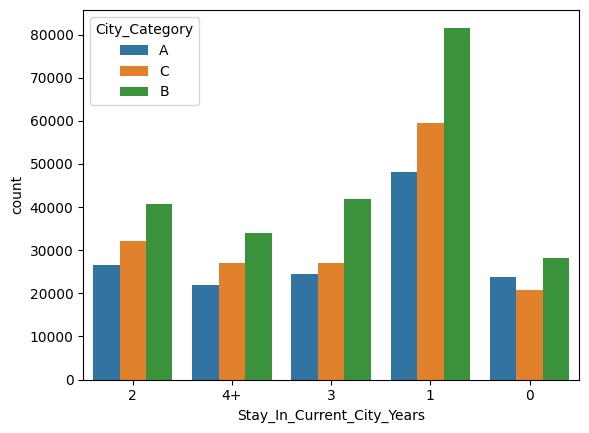

In [8]:
sns.countplot(x='Stay_In_Current_City_Years',hue='City_Category',data=df)

<Axes: xlabel='Stay_In_Current_City_Years', ylabel='count'>

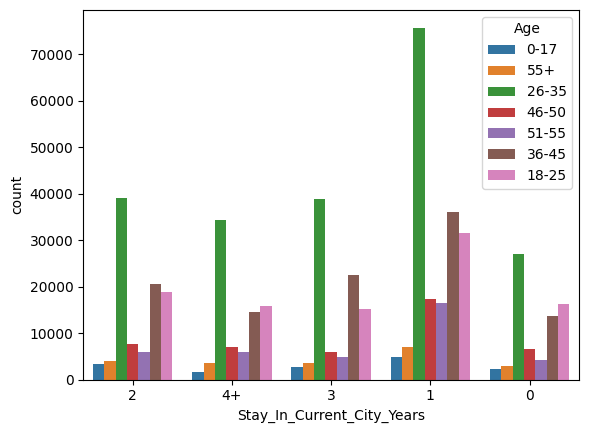

In [10]:
sns.countplot(x='Stay_In_Current_City_Years',hue='Age',data=df)

<Axes: xlabel='Stay_In_Current_City_Years'>

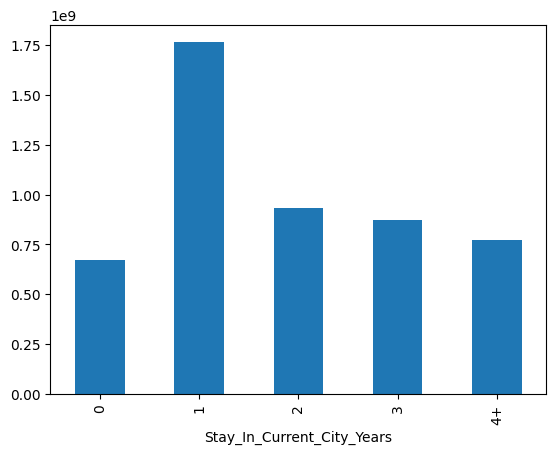

In [13]:
df.groupby('Stay_In_Current_City_Years')['Purchase'].sum().plot(kind='bar')

<Axes: xlabel='Occupation', ylabel='count'>

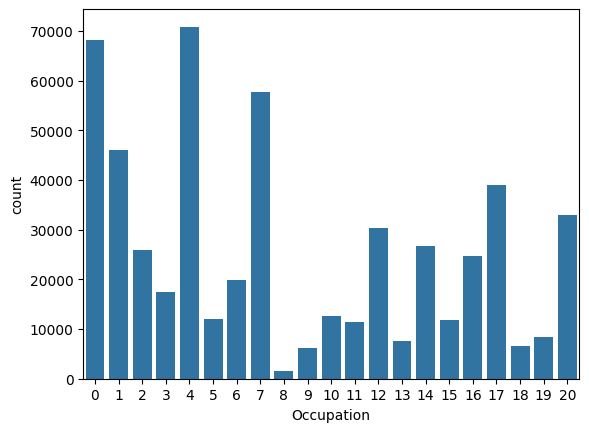

In [15]:
sns.countplot(x=df['Occupation'])

<Axes: xlabel='Occupation'>

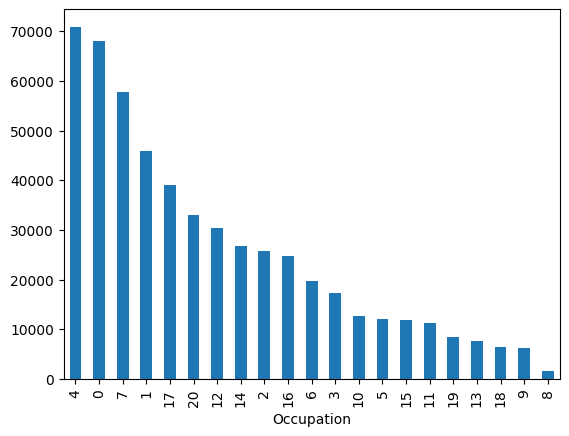

In [19]:
df.groupby('Occupation').size().sort_values(ascending=False).plot(kind='bar')

<Axes: xlabel='Occupation'>

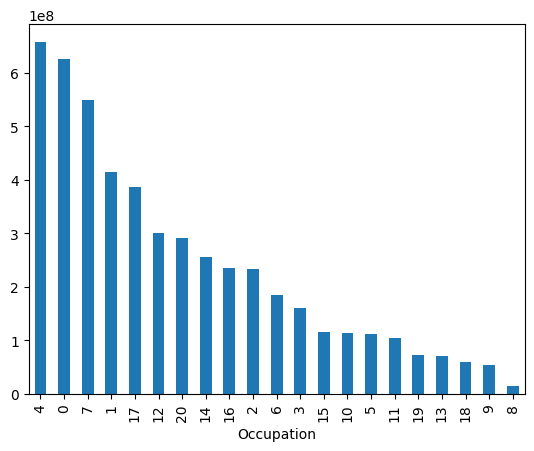

In [21]:
df.groupby('Occupation')['Purchase'].sum().sort_values(ascending=False).plot(kind='bar')

<Axes: xlabel='Occupation'>

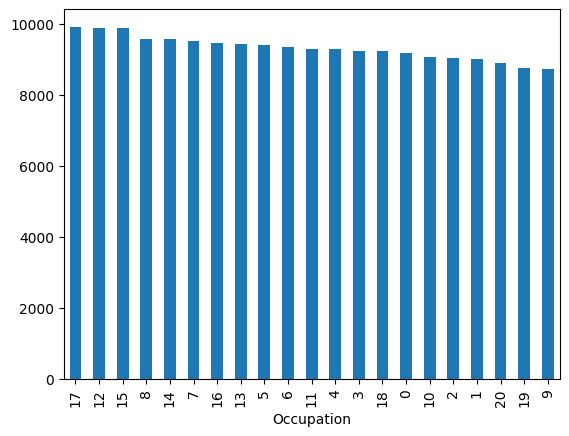

In [22]:
df.groupby('Occupation')['Purchase'].mean().sort_values(ascending=False).plot(kind='bar')

<Axes: xlabel='Occupation', ylabel='count'>

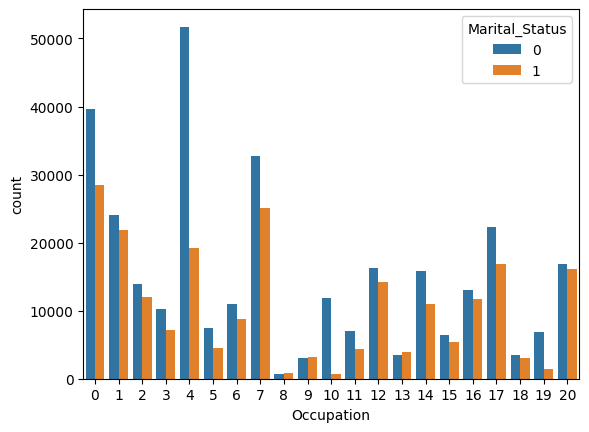

In [23]:
sns.countplot(x='Occupation',hue='Marital_Status',data=df)

<Axes: xlabel='Occupation', ylabel='count'>

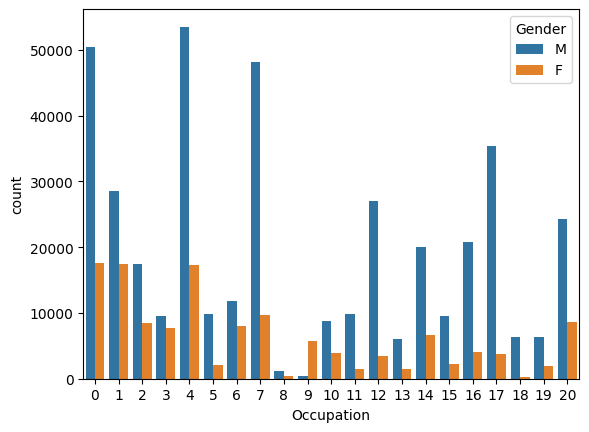

In [24]:
sns.countplot(x='Occupation',hue='Gender',data=df)

<Axes: xlabel='Occupation'>

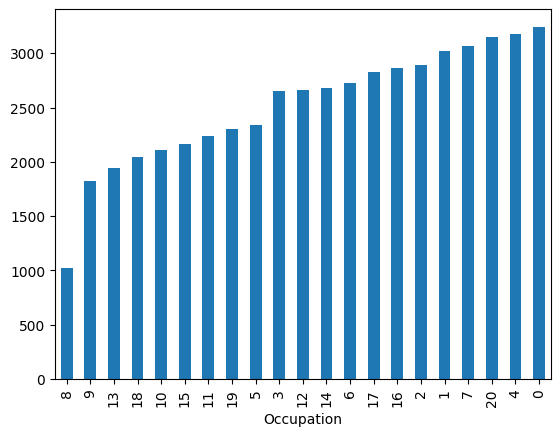

In [28]:
df.groupby('Occupation')['Product_ID'].nunique().sort_values().plot(kind='bar')

<Axes: xlabel='Product_Category_1'>

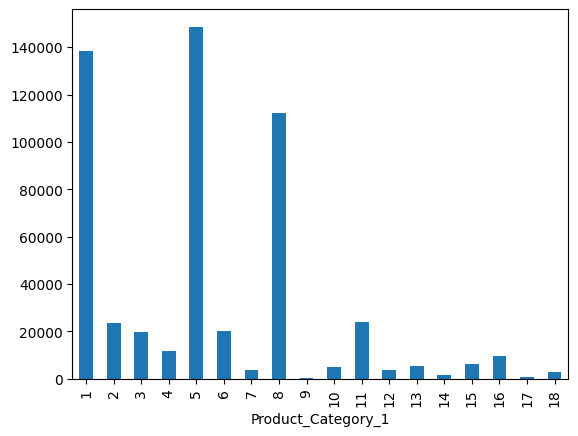

In [33]:
df.groupby('Product_Category_1').size().plot(kind='bar')

<Axes: xlabel='Product_Category_1'>

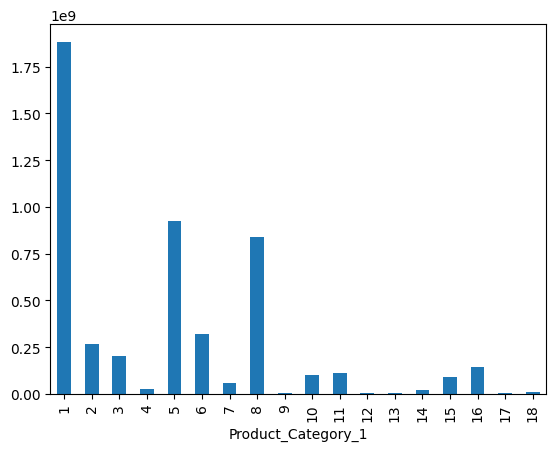

In [34]:
df.groupby('Product_Category_1')['Purchase'].sum().plot(kind='bar')

<Axes: xlabel='Product_Category_1'>

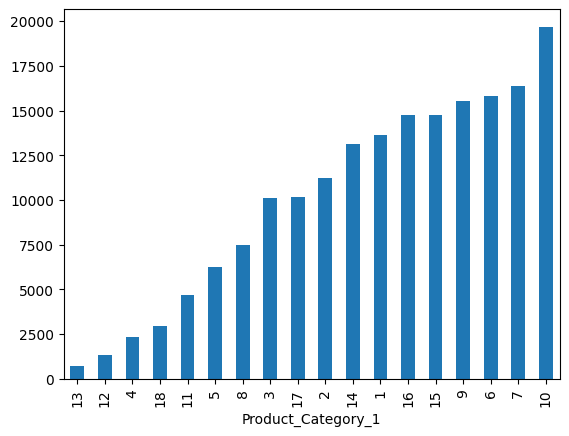

In [36]:
df.groupby('Product_Category_1')['Purchase'].mean().sort_values().plot(kind='bar')

<Axes: xlabel='Product_ID'>

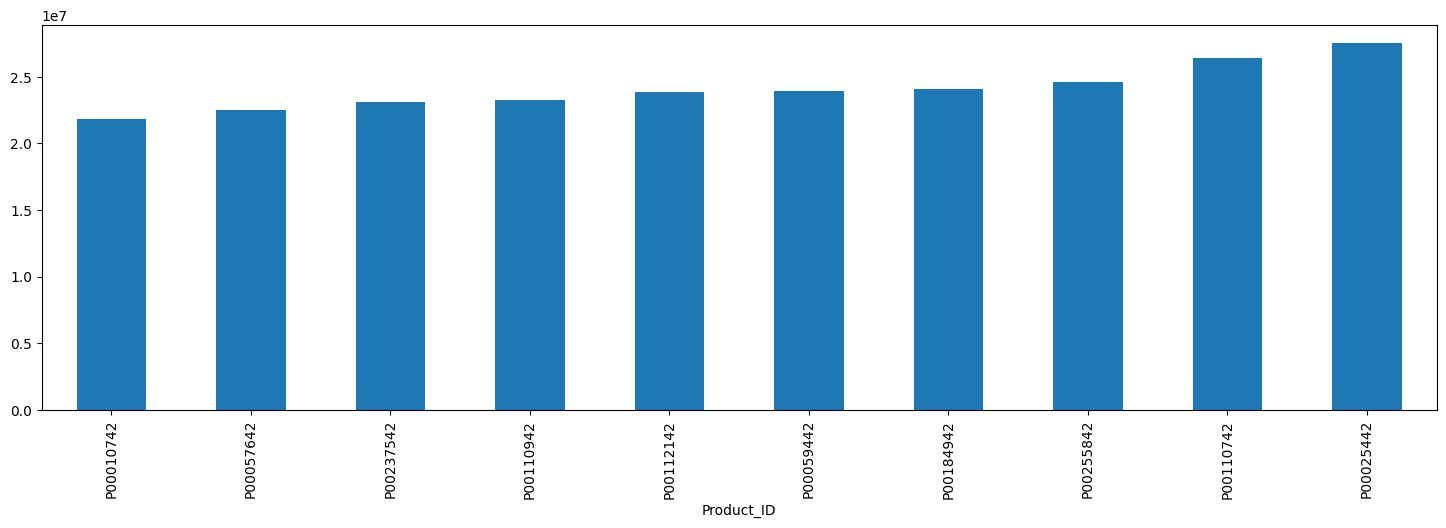

In [38]:
df.groupby('Product_ID')['Purchase'].sum().nlargest(10).sort_values().plot(kind='bar',figsize=(18,5))

<Axes: xlabel='Product_ID'>

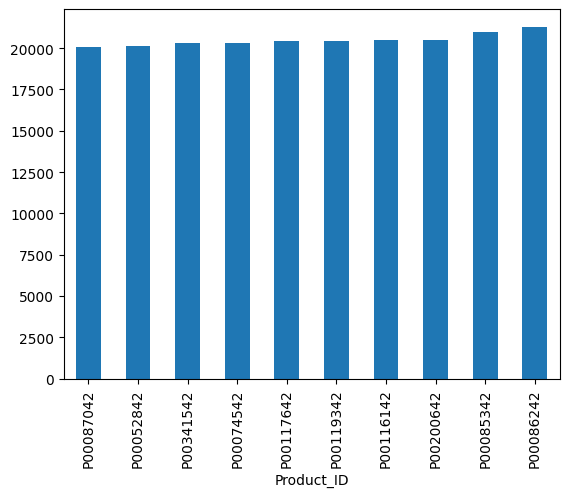

In [39]:
df.groupby('Product_ID')['Purchase'].mean().nlargest(10).sort_values().plot(kind='bar')

<Axes: xlabel='Product_ID'>

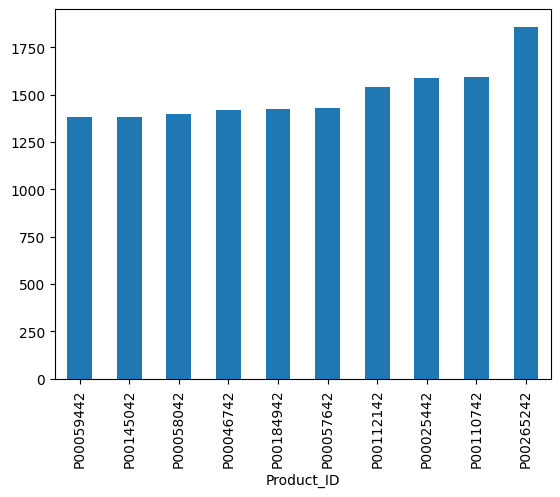

In [40]:
df.groupby('Product_ID')['Purchase'].size().nlargest(10).sort_values().plot(kind='bar')

# Combining Age and Marital Status

In [46]:
lst=[]
for i in range(len(df)):
    lst.append(df['Gender'][i]+'_'+str(df['Marital_Status'][i]))

In [47]:
df['Gender_Married']=lst

In [50]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Purchase,Gender_Married
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370,F_0
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200,F_0
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422,F_0
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057,F_0
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969,M_0


<Axes: xlabel='Gender_Married', ylabel='count'>

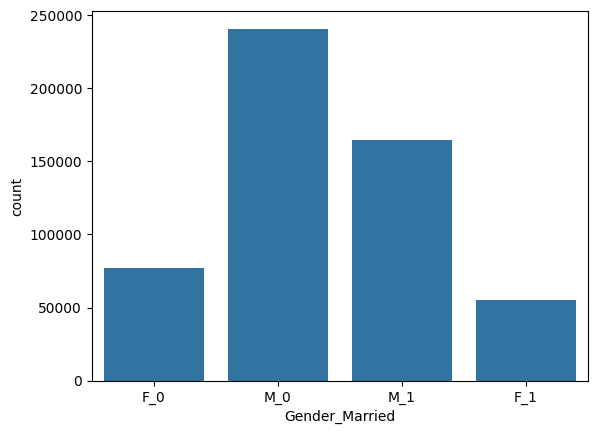

In [51]:
sns.countplot(x=df['Gender_Married'])

<Axes: xlabel='Age', ylabel='count'>

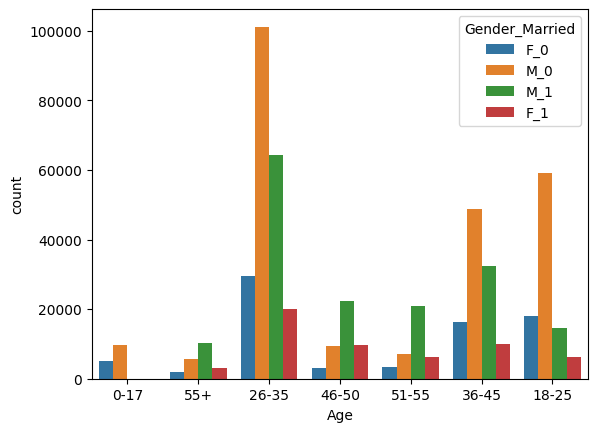

In [54]:
sns.countplot(x=df['Age'],hue=df['Gender_Married'])

<Axes: xlabel='Product_Category_1', ylabel='count'>

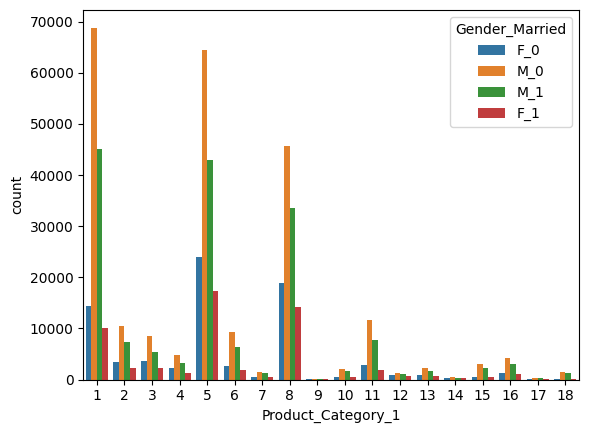

In [55]:
sns.countplot(x=df['Product_Category_1'],hue=df['Gender_Married'])

<Axes: xlabel='Stay_In_Current_City_Years', ylabel='count'>

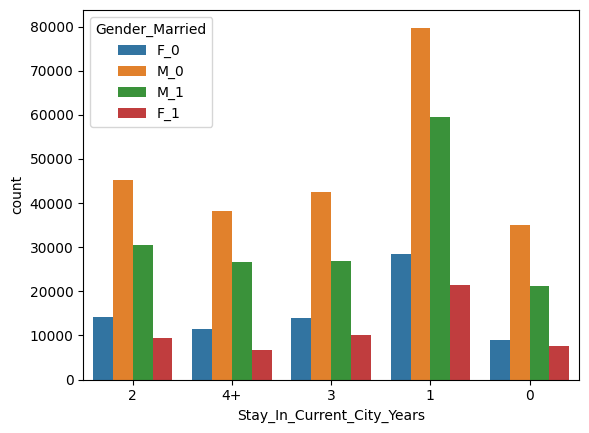

In [56]:
sns.countplot(x=df['Stay_In_Current_City_Years'],hue=df['Gender_Married'])